In [2]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='malgun gothic')

# mpg 데이터셋 사용

In [3]:
mpg_data = sns.load_dataset("mpg")
mpg_data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [4]:
mpg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


### 결측치처리(평균값으로)

In [5]:
mpg_data['horsepower'] = mpg_data['horsepower'].fillna(mpg_data['horsepower'].mean(), inplace=True)
mpg_data.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

### 범주형 데이터(origin)를 숫자로 변환 ('usa':0, 'europe':1, 'japan': 2)

In [6]:
mpg_data['origin_encoded'] = mpg_data['origin'].\
                                map({'usa': 0, 'europe': 1, 'japan': 2})
mpg_data.tail(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,origin_encoded
388,26.0,4,156.0,92.0,2585,14.5,82,usa,chrysler lebaron medallion,0
389,22.0,6,232.0,112.0,2835,14.7,82,usa,ford granada l,0
390,32.0,4,144.0,96.0,2665,13.9,82,japan,toyota celica gt,2
391,36.0,4,135.0,84.0,2370,13.0,82,usa,dodge charger 2.2,0
392,27.0,4,151.0,90.0,2950,17.3,82,usa,chevrolet camaro,0
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,0
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,1
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,0
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,0
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10,0


In [7]:
subset = mpg_data[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 
                                                     'model_year', 'origin_encoded']]
subset

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_encoded
0,18.0,8,307.0,130.0,3504,12.0,70,0
1,15.0,8,350.0,165.0,3693,11.5,70,0
2,18.0,8,318.0,150.0,3436,11.0,70,0
3,16.0,8,304.0,150.0,3433,12.0,70,0
4,17.0,8,302.0,140.0,3449,10.5,70,0
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,0
394,44.0,4,97.0,52.0,2130,24.6,82,1
395,32.0,4,135.0,84.0,2295,11.6,82,0
396,28.0,4,120.0,79.0,2625,18.6,82,0


In [ ]:
# !pip install scikit-learn

### 표준화

In [8]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()
subset_st = scaler.fit_transform(subset)

subset_st

array([[-0.7064387 ,  1.49819126,  1.0906037 , ..., -1.29549834,
        -1.62742629, -0.71514478],
       [-1.09075062,  1.49819126,  1.5035143 , ..., -1.47703779,
        -1.62742629, -0.71514478],
       [-0.7064387 ,  1.49819126,  1.19623199, ..., -1.65857724,
        -1.62742629, -0.71514478],
       ...,
       [ 1.08701694, -0.85632057, -0.56103873, ..., -1.4407299 ,
         1.62198339, -0.71514478],
       [ 0.57460104, -0.85632057, -0.70507731, ...,  1.10082237,
         1.62198339, -0.71514478],
       [ 0.95891297, -0.85632057, -0.71467988, ...,  1.39128549,
         1.62198339, -0.71514478]], shape=(398, 8))

In [14]:
# 표준화된 데이터를 데이터프레임으로 변환

subset_st_df = pd.DataFrame(subset_st, columns=subset.columns[0:])
subset_st_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_encoded
0,-0.706439,1.498191,1.090604,0.669196,0.630870,-1.295498,-1.627426,-0.715145
1,-1.090751,1.498191,1.503514,1.586599,0.854333,-1.477038,-1.627426,-0.715145
2,-0.706439,1.498191,1.196232,1.193426,0.550470,-1.658577,-1.627426,-0.715145
3,-0.962647,1.498191,1.061796,1.193426,0.546923,-1.295498,-1.627426,-0.715145
4,-0.834543,1.498191,1.042591,0.931311,0.565841,-1.840117,-1.627426,-0.715145
...,...,...,...,...,...,...,...,...
393,0.446497,-0.856321,-0.513026,-0.484111,-0.213324,0.011586,1.621983,-0.715145
394,2.624265,-0.856321,-0.925936,-1.375302,-0.993671,3.279296,1.621983,0.533222
395,1.087017,-0.856321,-0.561039,-0.536534,-0.798585,-1.440730,1.621983,-0.715145
396,0.574601,-0.856321,-0.705077,-0.667591,-0.408411,1.100822,1.621983,-0.715145


## 상관행렬

In [15]:
corr_matrix = subset_st_df.corr()
corr_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_encoded
mpg,1.000000,-0.775396,-0.804203,-0.771437,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.838939,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.893646,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.771437,0.838939,0.893646,1.000000,0.860574,-0.684259,-0.411651,-0.453669
weight,-0.831741,0.896017,0.932824,0.860574,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.684259,-0.417457,1.000000,0.288137,0.205873
model_year,0.579267,-0.348746,-0.370164,-0.411651,-0.306564,0.288137,1.000000,0.180662
origin_encoded,0.563450,-0.562543,-0.609409,-0.453669,-0.581024,0.205873,0.180662,1.000000


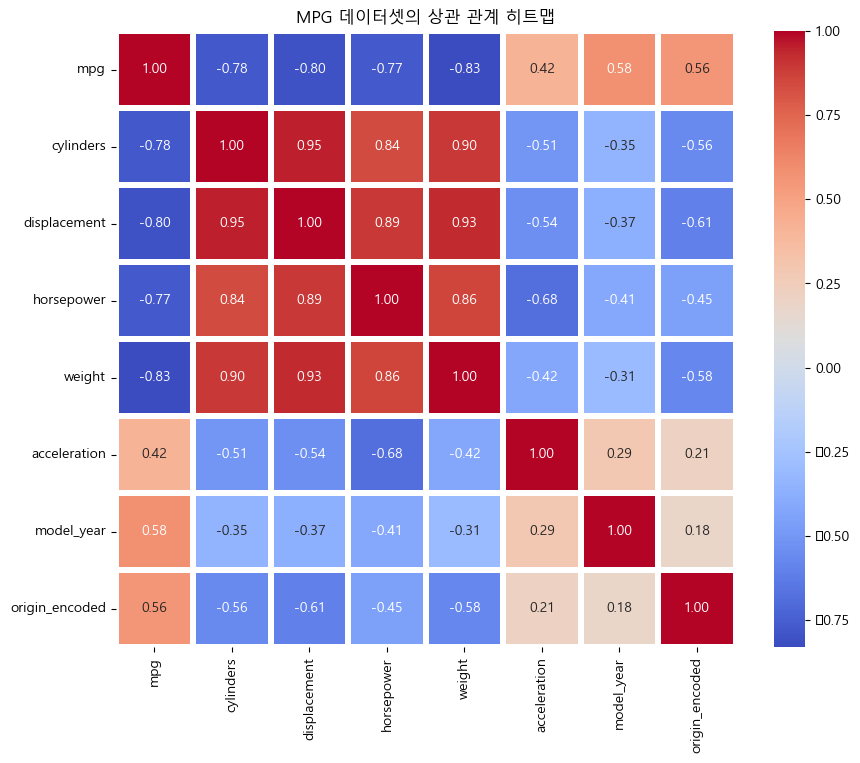

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=3)
plt.title('MPG 데이터셋의 상관 관계 히트맵')
plt.show()

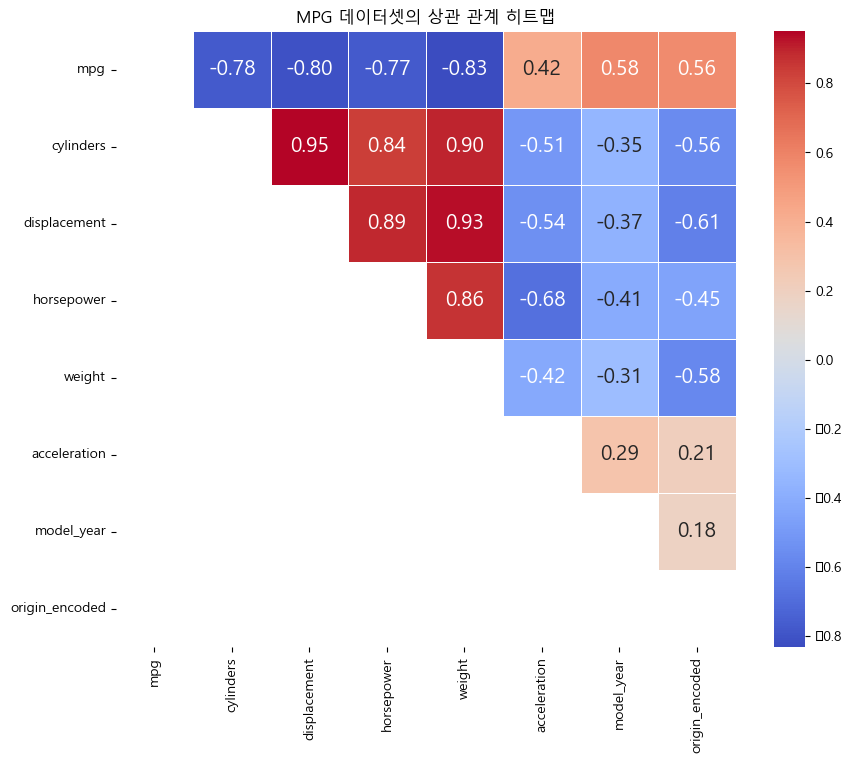

In [19]:
# m = np.triu(np.ones_like(corr_matrix, dtype=bool))  ## 상삼각부분 마스크 만들기
m = np.tril(np.ones_like(corr_matrix, dtype=bool))  ## 하삼각부분 마스크 만들기

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, mask=m,
            annot_kws={'size': 15})
plt.title('MPG 데이터셋의 상관 관계 히트맵')
plt.show()